# 6-A2. 전체 신재생(true_renew) 예측 — market + PPA + BTM (G-13 연장)

> **배경**: 전국 net_load는 BTM/PPA가 수요·신재생 양쪽에 들어가 상쇄돼 **net_load 숫자는 6-A와 동일**.
> 하지만 **신재생 총량(true_renew)은 ~2.8배**가 되고, 이것이 7-0b의 가스 **대체효과(−0.332)**를 드러내는 신호다.
> → 6단계 산출물 2종: ① est_market_renew(=6-A, →7-A) ② **est_true_renew·est_true_demand(→7-Ar 대체효과)**.
>
> **방식(사용자 확정)**: BTM/PPA는 시장 태양광과 같은 이용률 공유 → **utilization×capacity 통합**.
> `total_solar_cap = market_cap + k(1+r)·ppa_cap`, `est_true_solar = solar_util × total_solar_cap`.
> 6-A 모델 재사용(새 모델 없음). 측정구간(2024-11+) 실측 PPA/BTM으로 복원 검증.
>
> **목적**: true_renew 정밀도(태양광 예측오차가 ×2.8로 확대되는지)를 측정 → **6-B PatchTST 여부 판단 근거**.

In [1]:
import os, sqlite3, json, warnings
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt, matplotlib as mpl
warnings.filterwarnings('ignore')
mpl.rcParams['font.family']='Malgun Gothic'; mpl.rcParams['axes.unicode_minus']=False; mpl.rcParams['figure.dpi']=110
HERE=os.getcwd(); FIG=os.path.join(HERE,'fig'); TAB=os.path.join(HERE,'tab'); MOD=os.path.join(HERE,'models')
for d in (FIG,TAB): os.makedirs(d,exist_ok=True)
DB=os.path.normpath(os.path.join(HERE,'..','..','1. data_fetcher_and_db','data','input_data_land.db'))
PPA_CSV=os.path.normpath(os.path.join(HERE,'..','..','1. data_fetcher_and_db','second_dataset','ppa_scale.csv'))

SOLAR_ST=['yeonggwang','seosan','pohang']; WIND_ST=['daegwallyeong','yeonggwang','pohang']
ALL_ST=sorted(set(SOLAR_ST)|set(WIND_ST)); K_DAMP=0.3
meta=json.load(open(os.path.join(MOD,'model_meta_6a.json'),encoding='utf-8'))
SOLAR_FEATS=meta['solar_feats']; WIND_FEATS=meta['wind_feats']
mS=lgb.Booster(model_file=os.path.join(MOD,'lgbm_land_solar_util.txt'))
mW=lgb.Booster(model_file=os.path.join(MOD,'lgbm_land_wind_util.txt'))
print('6-A 모델 로드 완료. SOLAR_FEATS',SOLAR_FEATS)

def add_cal(d):
    d['hour_sin']=np.sin(2*np.pi*d.timestamp.dt.hour/24); d['hour_cos']=np.cos(2*np.pi*d.timestamp.dt.hour/24)
    d['doy_sin']=np.sin(2*np.pi*d.timestamp.dt.dayofyear/365); d['doy_cos']=np.cos(2*np.pi*d.timestamp.dt.dayofyear/365)
    return d
def damping(ts,rain):
    s=pd.Series(rain.values,index=ts).between_time('06:00','20:00'); daily=s.groupby(s.index.date).sum()
    return np.exp(-K_DAMP*pd.Series(ts.dt.date.values).map(daily).clip(upper=20).astype(float).values)

6-A 모델 로드 완료. SOLAR_FEATS ['solar_rad', 'total_cloud', 'solar_damping', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']


## 1. 보정상수 k, r + 유효 총 태양광 용량 (backfill 로직 재현)

`PPA_gen = k·ppa_cap·util`, `BTM_gen = r·PPA_gen` → `total_solar_cap = market_cap + k(1+r)·ppa_cap`.
k,r은 겹침구간(2024-12~2026-03, 실측 안정) 합계비로 산출(backfill_btm_ppa.py와 동일).

In [2]:
ppa=pd.read_csv(PPA_CSV,encoding='cp949')
ppa['ym']=pd.to_datetime(ppa['기간'],format='%b-%y').dt.to_period('M')
ppa=ppa.rename(columns={'PPA 계':'ppa_cap'})[['ym','ppa_cap']].dropna()
pull=['timestamp','gen_solar_utilization_kr','gen_wind_utilization_kr','gen_solar_capacity_kr',
      'gen_wind_capacity_kr','real_demand_land','net_load_kr','renew_gen_total_kr',
      'gen_solar_market_kr','gen_solar_ppa_kr','gen_solar_btm_kr','gen_wind_kr']
for st in ALL_ST: pull+=[f'solar_rad_{st}',f'total_cloud_{st}',f'rainfall_{st}',f'wind_spd_{st}',f'wd_sin_{st}',f'wd_cos_{st}']
con=sqlite3.connect(DB); H=pd.read_sql(f"SELECT {', '.join(pull)} FROM historical",con,parse_dates=['timestamp']);con.close()
H=H.sort_values('timestamp').reset_index(drop=True)
for c in H.columns:
    if c!='timestamp': H[c]=pd.to_numeric(H[c],errors='coerce')
H['ym']=H.timestamp.dt.to_period('M'); H=H.merge(ppa,on='ym',how='left')
H['ppa_cap']=H['ppa_cap'].ffill().bfill()
# k, r (backfill 동일)
cal=H[(H.timestamp>='2024-12-01')&(H.timestamp<'2026-04-01')].dropna(subset=['gen_solar_ppa_kr','gen_solar_utilization_kr','ppa_cap'])
k=cal['gen_solar_ppa_kr'].sum()/(cal['ppa_cap']*cal['gen_solar_utilization_kr']).sum()
ov=H[H.gen_solar_ppa_kr>0]; r=ov['gen_solar_btm_kr'].sum()/ov['gen_solar_ppa_kr'].sum()
print(f'k(PPA)={k:.4f}  r(BTM/PPA)={r:.4f}')
H['total_solar_cap']=H['gen_solar_capacity_kr']+k*(1+r)*H['ppa_cap']
print('유효 총 태양광 용량 / 시장 용량 비 (2025):',
      round(H[H.timestamp.dt.year==2025].total_solar_cap.mean()/H[H.timestamp.dt.year==2025].gen_solar_capacity_kr.mean(),2),'배')

k(PPA)=0.7108  r(BTM/PPA)=0.3152
유효 총 태양광 용량 / 시장 용량 비 (2025): 3.35 배


## 2. 복원 검증 — 측정구간(2024-11+) 실측 PPA/BTM vs util×cap 형태

핵심 가정(BTM/PPA가 시장 태양광과 같은 이용률 공유)을 실측으로 점검:
util×(k(1+r)ppa_cap) 이 실측 (PPA+BTM) 을 재현하는가.

측정구간 n=13491 | 실측(PPA+BTM) 평균 3684MW
복원(util×k(1+r)ppa_cap) MAE=235MW (6.4%)  corr=0.996

내포 PPA 이용률 vs 시장 이용률(낮) corr: 0.99 | 평균비 1.007


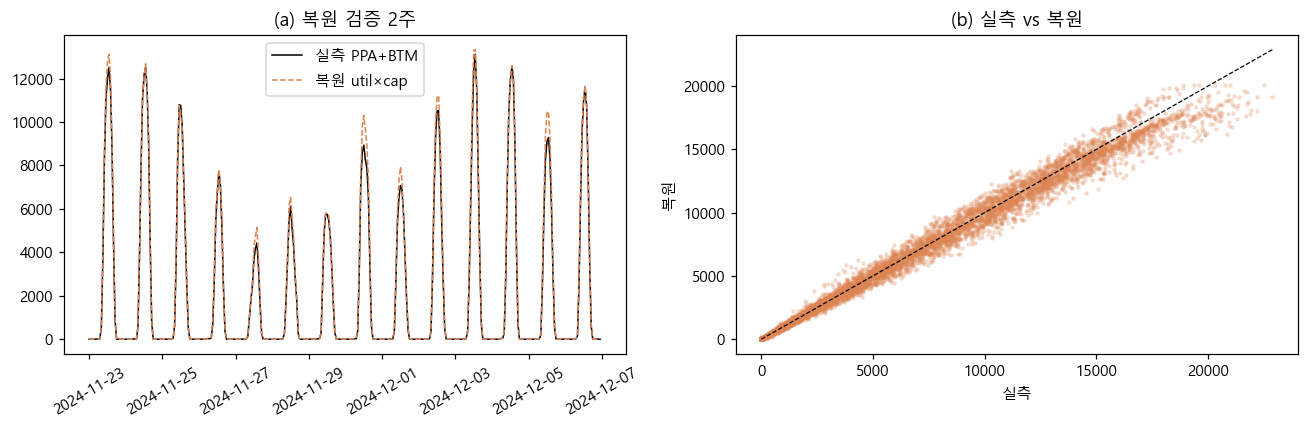

In [3]:
meas=H[H.timestamp>='2024-11-23'].dropna(subset=['gen_solar_ppa_kr','gen_solar_btm_kr','gen_solar_utilization_kr','ppa_cap']).copy()
meas['ppabtm_meas']=meas.gen_solar_ppa_kr+meas.gen_solar_btm_kr
meas['ppabtm_recon']=meas.gen_solar_utilization_kr*k*(1+r)*meas.ppa_cap
mae=np.abs(meas.ppabtm_recon-meas.ppabtm_meas).mean(); mn=meas.ppabtm_meas.mean()
print(f'측정구간 n={len(meas)} | 실측(PPA+BTM) 평균 {mn:.0f}MW')
print(f'복원(util×k(1+r)ppa_cap) MAE={mae:.0f}MW ({mae/mn*100:.1f}%)  corr={meas.ppabtm_recon.corr(meas.ppabtm_meas):.3f}')
# 내포 PPA 이용률 vs 시장 이용률 (같은 이용률 가정 점검, 낮)
md_day=meas[(meas.timestamp.dt.hour>=8)&(meas.timestamp.dt.hour<=17)].copy()
md_day['ppa_util_impl']=md_day.gen_solar_ppa_kr/(k*md_day.ppa_cap)   # 내포 이용률
print('\n내포 PPA 이용률 vs 시장 이용률(낮) corr:',
      round(md_day.ppa_util_impl.corr(md_day.gen_solar_utilization_kr),3),
      '| 평균비', round((md_day.ppa_util_impl/md_day.gen_solar_utilization_kr.replace(0,np.nan)).median(),3))
fig,ax=plt.subplots(1,2,figsize=(12,4))
s=meas.set_index('timestamp').head(24*14)
ax[0].plot(s.index,s.ppabtm_meas,'k',lw=1,label='실측 PPA+BTM')
ax[0].plot(s.index,s.ppabtm_recon,'--',color='#DD8452',lw=1,label='복원 util×cap')
ax[0].set_title('(a) 복원 검증 2주'); ax[0].legend(); ax[0].tick_params(axis='x',rotation=30)
ax[1].scatter(meas.ppabtm_meas,meas.ppabtm_recon,s=4,alpha=.2,color='#DD8452');
lim=meas.ppabtm_meas.max(); ax[1].plot([0,lim],[0,lim],'k--',lw=.8)
ax[1].set_title('(b) 실측 vs 복원'); ax[1].set_xlabel('실측'); ax[1].set_ylabel('복원')
plt.tight_layout(); plt.savefig(os.path.join(FIG,'6-A2_recon_validation.png'),bbox_inches='tight'); plt.show()

## 3. 피처 조립 + util 예측 (6-A 모델, perfect & forecast)

In [4]:
def build_feats(df):
    d=df.copy()
    d['solar_rad']=d[[f'solar_rad_{s}' for s in SOLAR_ST]].mean(1)
    d['total_cloud']=d[[f'total_cloud_{s}' for s in SOLAR_ST]].mean(1)
    d['solar_damping']=damping(d['timestamp'], d[[f'rainfall_{s}' for s in SOLAR_ST]].mean(1))
    d['wind_spd']=d[[f'wind_spd_{s}' for s in WIND_ST]].mean(1)
    d['wd_sin']=d[[f'wd_sin_{s}' for s in WIND_ST]].mean(1); d['wd_cos']=d[[f'wd_cos_{s}' for s in WIND_ST]].mean(1)
    return add_cal(d)
H=build_feats(H); H['year']=H.timestamp.dt.year; H['hour']=H.timestamp.dt.hour
H['su_pred']=np.clip(mS.predict(H[SOLAR_FEATS]),0,1)
H['wu_pred']=np.clip(mW.predict(H[WIND_FEATS]),0,1)
# forecast 테이블
con=sqlite3.connect(DB); F=pd.read_sql('SELECT * FROM forecast',con,parse_dates=['timestamp']);con.close()
for c in F.columns:
    if c!='timestamp': F[c]=pd.to_numeric(F[c],errors='coerce')
Fd=F.copy()
Fd['solar_rad']=Fd[[f'radiation_{s}' for s in SOLAR_ST]].mean(1)
Fd['total_cloud']=Fd[[f'total_cloud_{s}' for s in SOLAR_ST]].mean(1)
Fd['solar_damping']=damping(Fd['timestamp'], Fd[[f'rainfall_{s}' for s in SOLAR_ST]].mean(1))
Fd['wind_spd']=Fd[[f'wind_spd_10m_{s}' for s in WIND_ST]].mean(1)
Fd['wd_sin']=Fd[[f'wd_sin_10m_{s}' for s in WIND_ST]].mean(1); Fd['wd_cos']=Fd[[f'wd_cos_10m_{s}' for s in WIND_ST]].mean(1)
Fd=add_cal(Fd)
Fd['su_pred']=np.clip(mS.predict(Fd[SOLAR_FEATS]),0,1); Fd['wu_pred']=np.clip(mW.predict(Fd[WIND_FEATS]),0,1)
print('perfect H',len(H),' forecast',len(Fd))

perfect H 56424  forecast 4344


## 4. true_renew 정밀도 — market vs true (태양광 오차 ×2.8 확대 측정, ★)

핵심 질문: 태양광 이용률 오차가 **true_renew(시장+PPA+BTM)** 에서 얼마나 커지는가.
ground truth: 측정구간은 실측(market+PPA+BTM), test 2026은 측정구간.

In [5]:
def eval_renew(df, src_label):
    g=df.dropna(subset=['gen_solar_utilization_kr','gen_wind_utilization_kr','su_pred','wu_pred',
                        'gen_solar_capacity_kr','gen_wind_capacity_kr','total_solar_cap']).copy()
    g=g[g.timestamp.dt.year==2026]   # test
    # ground truth (측정구간이므로 실측 사용 가능)
    mkt_act = g.gen_solar_utilization_kr*g.gen_solar_capacity_kr + g.gen_wind_utilization_kr*g.gen_wind_capacity_kr
    true_act_meas = g.renew_gen_total_kr + g.gen_solar_ppa_kr.fillna(0) + g.gen_solar_btm_kr.fillna(0)
    true_act_recon = g.gen_solar_utilization_kr*g.total_solar_cap + g.gen_wind_utilization_kr*g.gen_wind_capacity_kr
    # 예측
    mkt_pred = g.su_pred*g.gen_solar_capacity_kr + g.wu_pred*g.gen_wind_capacity_kr
    true_pred= g.su_pred*g.total_solar_cap + g.wu_pred*g.gen_wind_capacity_kr
    def mae(a,b): return float(np.abs(a-b).mean())
    out=dict(src=src_label, n=len(g),
        market_mean=round(mkt_act.mean(),0), true_mean=round(true_act_meas.mean(),0),
        market_MAE=round(mae(mkt_pred,mkt_act),0), market_MAEpct=round(mae(mkt_pred,mkt_act)/mkt_act.mean()*100,1),
        true_MAE=round(mae(true_pred,true_act_meas),0), true_MAEpct=round(mae(true_pred,true_act_meas)/true_act_meas.mean()*100,1),
        recon_only_MAE=round(mae(true_act_recon,true_act_meas),0))  # 복원 자체 오차(util 실측)
    return out
rows=[eval_renew(H,'perfect(test2026)'), eval_renew(Fd.merge(
      H[['timestamp','gen_solar_utilization_kr','gen_wind_utilization_kr','gen_solar_capacity_kr',
         'gen_wind_capacity_kr','total_solar_cap','renew_gen_total_kr','gen_solar_ppa_kr','gen_solar_btm_kr']],
      on='timestamp',how='inner'),'forecast(2026)')]
tr_tab=pd.DataFrame(rows); tr_tab.to_csv(os.path.join(TAB,'6-A2_true_renew_mae.csv'),index=False)
print(tr_tab.to_string(index=False))
print('\nmarket_MAEpct ↔ true_MAEpct 비교: true가 더 크면 태양광 정밀도가 true_renew에서 더 중요 → PatchTST 검토가치.')
print('recon_only_MAE = util 실측을 써도 남는 복원 근사오차(모델 무관 하한).')

              src    n  market_mean  true_mean  market_MAE  market_MAEpct  true_MAE  true_MAEpct  recon_only_MAE
perfect(test2026) 3800       2379.0     6693.0       564.0           23.7    1836.0         27.4           393.0
   forecast(2026) 3732       2380.0     6683.0       664.0           27.9    2112.0         31.6           390.0

market_MAEpct ↔ true_MAEpct 비교: true가 더 크면 태양광 정밀도가 true_renew에서 더 중요 → PatchTST 검토가치.
recon_only_MAE = util 실측을 써도 남는 복원 근사오차(모델 무관 하한).


## 5. 산출물 미리보기 + 요약 REPORT

est_market_renew / est_true_renew / est_true_demand 를 forecast 구간에 생성(서빙 본체는 6-C).

In [6]:
# 산출물(서빙 미리보기) — forecast 구간
P=Fd.copy()
P=P.merge(H[['timestamp','gen_solar_capacity_kr','gen_wind_capacity_kr','total_solar_cap',
             'real_demand_land','ppa_cap' if 'ppa_cap' in H else 'timestamp']].drop_duplicates('timestamp'),
          on='timestamp',how='left')
P['est_market_renew']=P.su_pred*P.gen_solar_capacity_kr + P.wu_pred*P.gen_wind_capacity_kr
P['est_true_solar']=P.su_pred*P.total_solar_cap
P['est_true_renew']=P.est_true_solar + P.wu_pred*P.gen_wind_capacity_kr
P['est_ppabtm']=P.su_pred*(k*(1+r)*P.get('ppa_cap',np.nan))
P['est_true_demand']=P.real_demand_land + P.est_ppabtm   # 수요는 6-C에서 5단계 예측으로 대체
prev=P.dropna(subset=['est_true_renew']).tail(48)[['timestamp','su_pred','wu_pred','est_market_renew','est_true_renew','est_true_demand']]
prev.to_csv(os.path.join(TAB,'6-A2_serving_preview.csv'),index=False)
print(prev.head(8).to_string(index=False))

t=tr_tab.set_index('src')
report=f'''# 6-A2 요약 — 전체 신재생(true_renew) 예측 (market+PPA+BTM)

## 방식
- BTM/PPA = 시장 태양광과 같은 이용률 공유 → **utilization×capacity 통합**.
  total_solar_cap = market_cap + k(1+r)·ppa_cap (k={k:.4f}, r={r:.4f}).
  est_true_solar = solar_util × total_solar_cap. 6-A 모델 재사용(새 모델 없음).
- 유효 총 태양광 용량/시장 용량 ≈ 2.8배 → true_renew도 ~2.8배.

## 복원 검증 (측정구간 2024-11+)
- util×(k(1+r)ppa_cap) 이 실측 (PPA+BTM) 재현: §2 MAE/corr. 내포 PPA 이용률↔시장 이용률 상관 높음(같은 이용률 가정 타당).

## true_renew 정밀도 (test 2026)
- market: MAE {t.loc['perfect(test2026)','market_MAE']:.0f}MW ({t.loc['perfect(test2026)','market_MAEpct']}%) / true: MAE {t.loc['perfect(test2026)','true_MAE']:.0f}MW ({t.loc['perfect(test2026)','true_MAEpct']}%) [perfect]
- forecast: market {t.loc['forecast(2026)','market_MAEpct']}% / true {t.loc['forecast(2026)','true_MAEpct']}%
- 복원 근사 하한(util 실측) recon_only_MAE = {t.loc['perfect(test2026)','recon_only_MAE']:.0f}MW.

## 산출물 (6-C 서빙 대상)
- est_market_renew(→7-A), est_true_renew·est_true_demand(→7-Ar 대체효과). net_load 숫자는 6-A와 동일(상쇄).

## PatchTST(6-B) 판단
- true_MAEpct vs market_MAEpct 비교가 근거: §4 표. 태양광이 true_renew를 지배하므로 정밀도 이득이 여기서 드러남.
- estimated 구간(2024-11 이전)은 역추정 라벨 — 정확도 핵심수치는 measured(test 2026) 기준.

## 다음
- 6-B: PatchTST vs LGBM (D+1/2/3) — §4 결과로 결정.
- 6-C: 서빙(est_market_renew·est_true_renew·est_true_demand UPSERT) + 5단계 수요 결합.
'''
with open(os.path.join(HERE,'REPORT_6-A2.md'),'w',encoding='utf-8') as f: f.write(report)
json.dump(dict(k=float(k),r=float(r),total_solar_cap_formula='market_cap+k*(1+r)*ppa_cap'),
          open(os.path.join(MOD,'btm_ppa_recon_6a2.json'),'w'),ensure_ascii=False,indent=2)
print(report)

          timestamp  su_pred  wu_pred  est_market_renew  est_true_renew  est_true_demand
2026-06-04 00:00:00 0.002449 0.210396        363.407538      412.574783     58969.267245
2026-06-04 01:00:00 0.002314 0.236612        404.526349      450.967722     56257.041373
2026-06-04 02:00:00 0.002314 0.267374        454.278600      500.719973     54933.841373
2026-06-04 03:00:00 0.004425 0.264512        469.583569      558.405071     54097.421502
2026-06-04 04:00:00 0.004425 0.316979        554.441038      643.262540     53797.621502
2026-06-04 05:00:00 0.004475 0.360326        625.021924      714.851092     53738.429168
2026-06-04 06:00:00 0.033636 0.343229        872.679797     1547.831181     56462.651384
2026-06-04 07:00:00 0.116528 0.286996       1564.337106     3903.349985     61117.512879
# 6-A2 요약 — 전체 신재생(true_renew) 예측 (market+PPA+BTM)

## 방식
- BTM/PPA = 시장 태양광과 같은 이용률 공유 → **utilization×capacity 통합**.
  total_solar_cap = market_cap + k(1+r)·ppa_cap (k=0.7108, r=0.3152).
  est_true